In [10]:
from google.colab import drive

import os
import sys

import pandas as pd
import numpy as np
from PIL import Image, ImageOps

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import gc

import tensorflow as tf

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight

from sklearn import metrics

import matplotlib.cm as cm
from matplotlib.colors import ListedColormap

import random

In [28]:
df_metricas = pd.DataFrame(columns = ['Rede', 'Treino', 'Validacao'])

In [29]:
df_metricas.loc[len(df_metricas)] = ['Autoencoder (Treinado)', 0.37, 0.36]
df_metricas.loc[len(df_metricas)] = ['InceptionResNetV2', 0.830, 0.736]
df_metricas.loc[len(df_metricas)] = ['ResNet101V2', 0.880, 0.795]
df_metricas.loc[len(df_metricas)] = ['Xception', 0.842, 0.761]
df_metricas.loc[len(df_metricas)] = ['ResNet50V2 (Baseline)', 0.903, 0.803]

In [30]:
df_metricas = df_metricas.sort_values('Validacao', ascending = False)
display(df_metricas)

Rede  Treino  Validacao
4   ResNet50V2 (Baseline)   0.903      0.803
2             ResNet101V2   0.880      0.795
3                Xception   0.842      0.761
1       InceptionResNetV2   0.830      0.736
0  Autoencoder (Treinado)   0.370      0.360

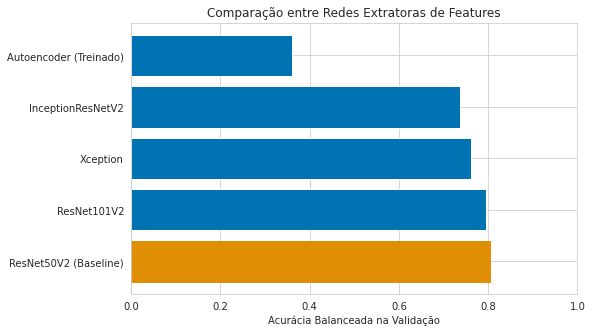

In [32]:
figsize = [8, 5]
paleta_cores = sns.color_palette("colorblind")
with sns.axes_style("whitegrid"):
  fig, ax = plt.subplots(1, 1, figsize = figsize)
  barlist = ax.barh(df_metricas['Rede'], df_metricas['Validacao'], color = paleta_cores[0])
  barlist[0].set_color(paleta_cores[1])
  #ax.set_ylabel('Rede Extratora de Features')
  ax.set_xlabel('Acurácia Balanceada na Validação')
  ax.set_title('Comparação entre Redes Extratoras de Features')
  ax.set_xlim([0, 1])
  plt.show()